# Title: Mini ProjectData Mining and Data Preprocessing for Knowledge Discovery


# Project Theme

## “From Raw Data to Knowledge: A Data Mining Case Study”

Modern systems generate massive data, but meaningful knowledge emerges only after systematic preprocessing and analysis. This mini-project explores the early stages of the Knowledge Discovery in Databases (KDD) process using a real-world medical dataset, the UCI Heart Disease Dataset.

**Core Objectives:**
*   Understanding raw data
*   Data representation
*   Similarity analysis
*   Data quality assessment
*   Missing value handling
*   Building ML-ready datasets


## Step 1 - Dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
from sklearn.impute import SimpleImputer, KNNImputer

# Note: IterativeImputer is experimental, we need to enable it
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Dataset Loading (Recommended)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"
]

# We use na_values="?" because the Cleveland dataset represents missing values with "?"
df = pd.read_csv(url, names=columns, na_values="?")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 2 - Problem Understanding

**1. Source of the dataset**: UCI Machine Learning Repository - Heart Disease Dataset (specifically the processed Cleveland database).

**2. Application domain**: Healthcare analytics and Medical Diagnostics.

**3. Knowledge that can be extracted**: Patterns and correlations between patient physiological attributes (like cholesterol, blood pressure, ECG results) and the likelihood of heart disease. Discovery of high-risk physiological indicators.

**4. Real-world decisions supported**: Early diagnosis of heart disease, prioritizing treatment for high-risk patients, and suggesting preventative lifestyle changes based on identified risk factors.

## Phase 1 � Understanding Data Objects and Attributes

**1. Define:**
*   **Data object**: A single row or instance in the dataset representing an individual patient with their medical measurements.
*   **Attributes/features**: Formatted characteristics or measurements taken from the patient (e.g., age, sex, cholesterol levels).

**2. Represent dataset as:**
$X = (x_1, x_2, \dots, x_d)$ where each $x_i$ is a feature (age, sex, etc.) and $d = 14$ including the target, so $X = (\text{age}, \text{sex}, \text{cp}, \text{trestbps}, \text{chol}, \text{fbs}, \text{restecg}, \text{thalach}, \text{exang}, \text{oldpeak}, \text{slope}, \text{ca}, \text{thal}, \text{target})$.

**3. Classification Table:**

| Attribute | Type | Example Values |
| :--- | :--- | :--- |
| **age** | Numerical (Ratio) | 63.0, 37.0 |
| **sex** | Binary (Nominal) | 1.0 (male), 0.0 (female) |
| **cp** (chest pain type) | Nominal | 1.0 (typical angina), 4.0 (asymptomatic) |
| **trestbps** (resting blood pressure) | Numerical (Interval) | 145.0, 130.0 |
| **chol** (cholesterol) | Numerical (Ratio) | 233.0, 250.0 |
| **fbs** (fasting blood sugar > 120 mg/dl) | Binary (Nominal) | 1.0 (true), 0.0 (false) |
| **restecg** (resting ECG) | Nominal | 0.0 (normal), 2.0 (hypertrophy) |
| **thalach** (max heart rate) | Numerical (Ratio) | 150.0, 187.0 |
| **exang** (exercise induced angina) | Binary (Nominal) | 1.0 (yes), 0.0 (no) |
| **oldpeak** (ST depression) | Numerical (Ratio) | 2.3, 1.5 |
| **slope** (peak exercise ST seg) | Ordinal | 1.0 (upsloping), 2.0 (flat), 3.0 (down) |
| **ca** (number of major vessels) | Numerical (Ratio) | 0.0, 3.0 |
| **thal** | Nominal | 3.0 (normal), 6.0 (fixed defect), 7.0 (reversable) |
| **target** (heart disease status) | Ordinal/Binary | 0 (no disease), 1-4 (disease severity) |

## Phase 2 � Exploratory Data Analysis

In [23]:
# Dataset shape and size
print(f"Dataset Shape: {df.shape}")
print(f"Number of instances (rows): {df.shape[0]}")
print(f"Number of attributes (columns): {df.shape[1]}")

# Summary statistics
display(df.describe())

Dataset Shape: (303, 14)
Number of instances (rows): 303
Number of attributes (columns): 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


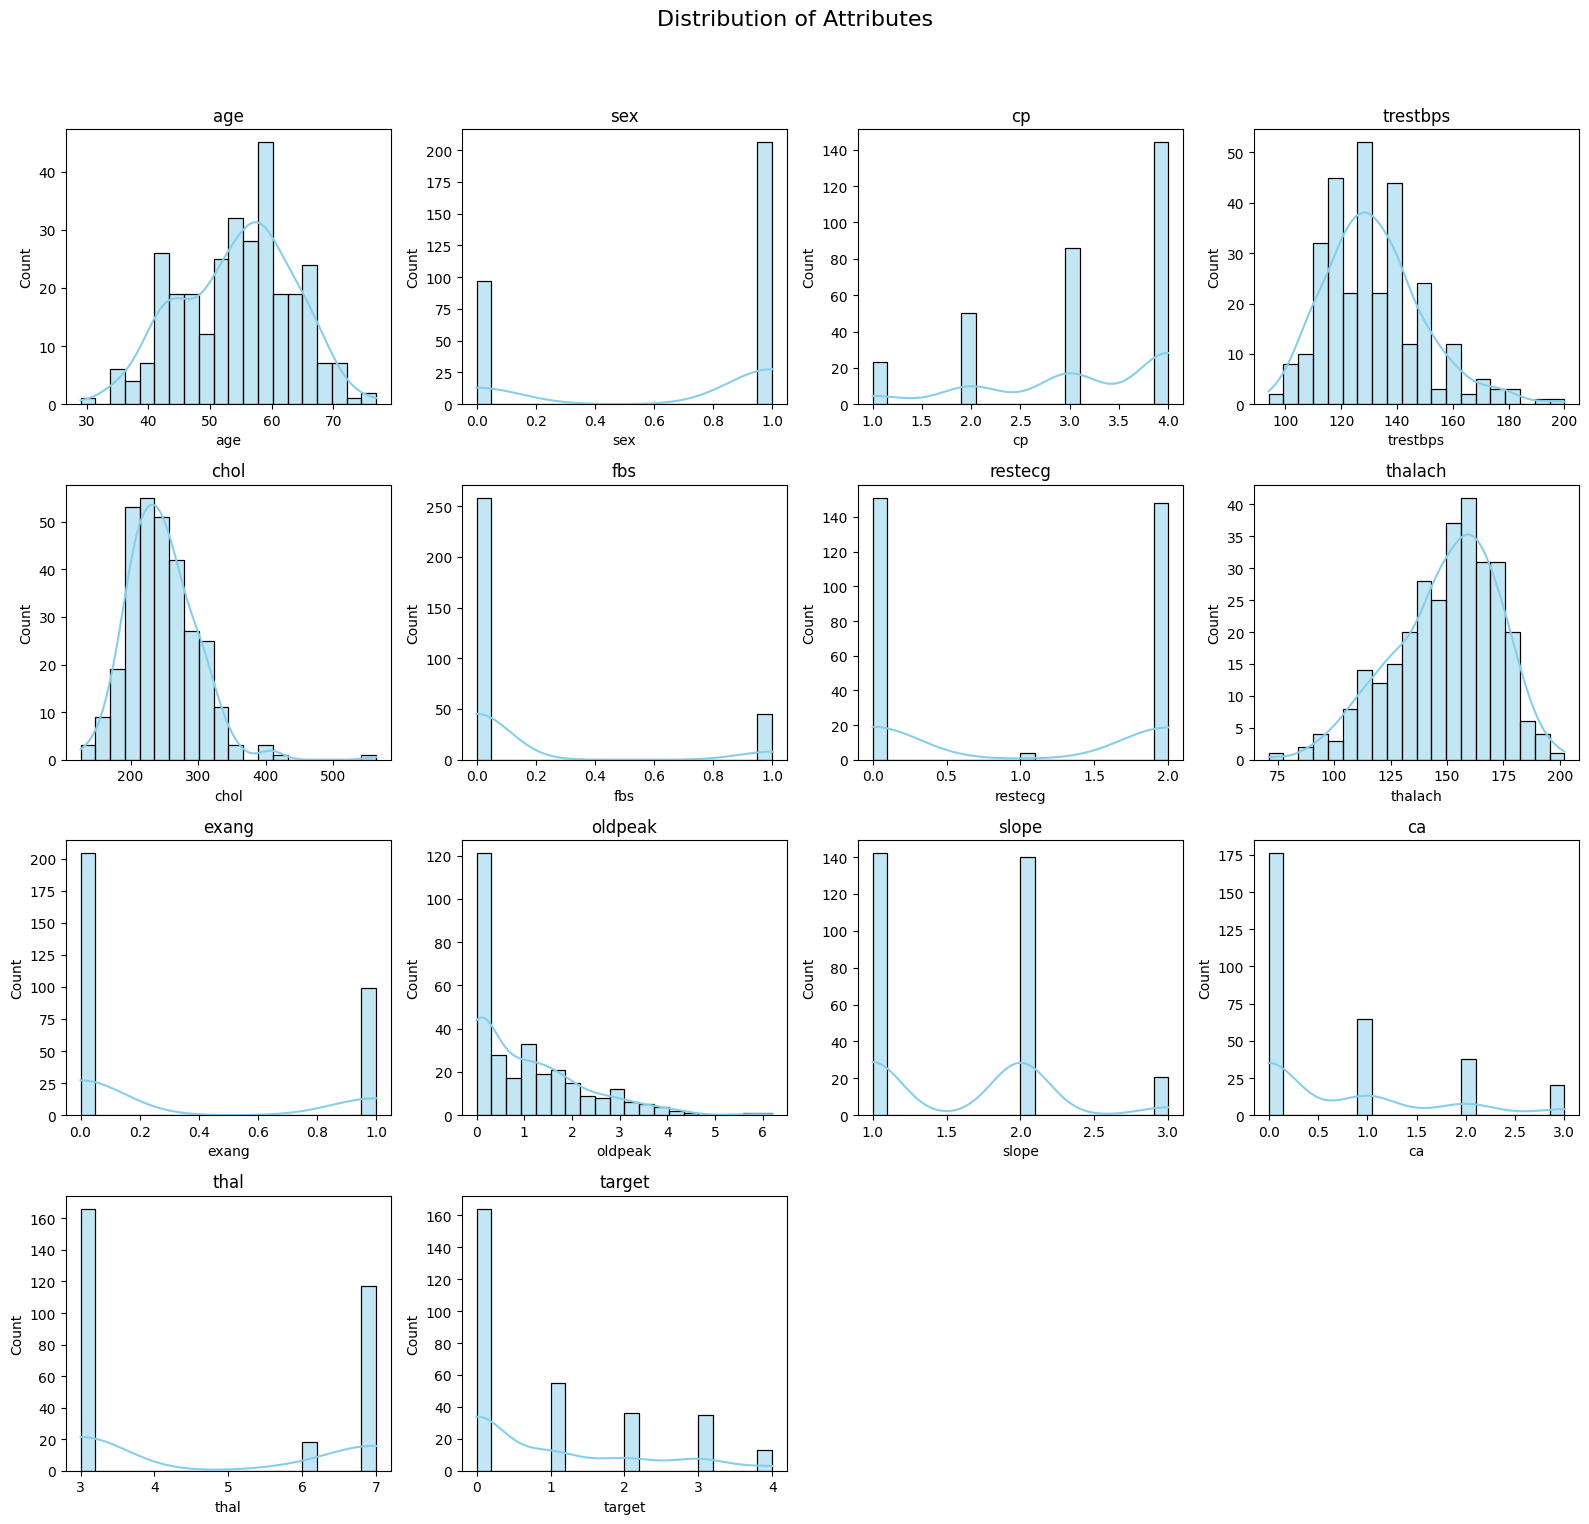

In [24]:
# Distribution plots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Distribution of Attributes', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=20, color='skyblue')
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

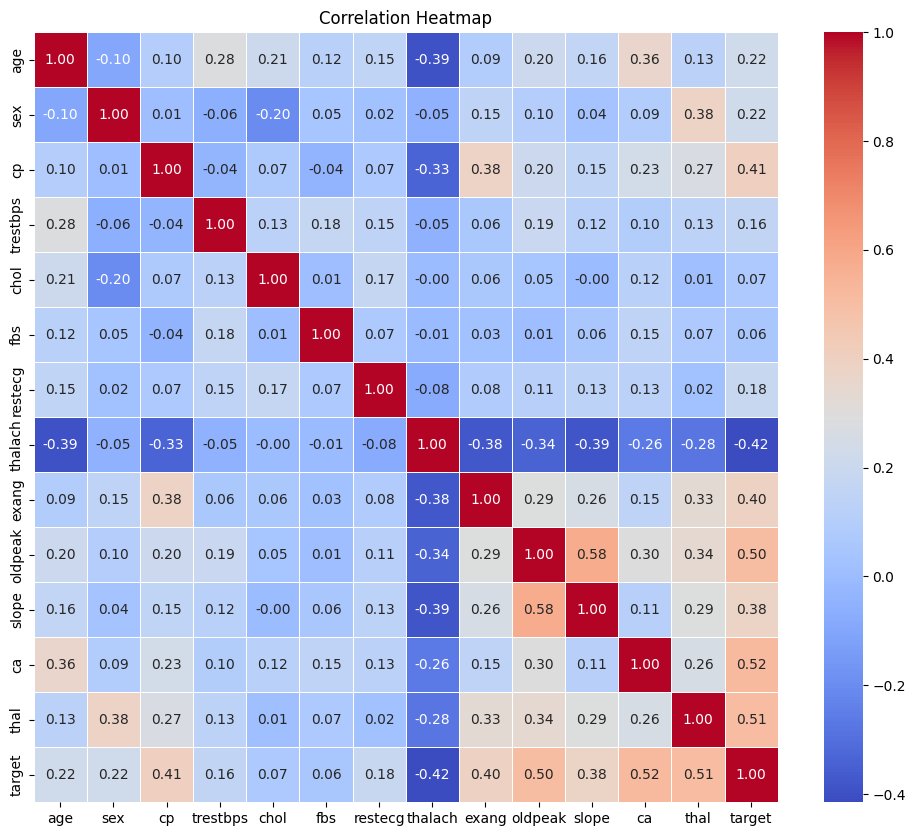

In [25]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Answers:**
*   **Which attributes appear important?** From the correlation matrix, attributes like `cp`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, and `thal` show a stronger correlation (positive or negative) with the `target` variable.
*   **Are there redundant features?** There are no perfectly correlated features (correlation near 1 or -1), meaning there's not severe redundancy. However, `slope` and `oldpeak` are moderately correlated (0.58), which makes physiological sense.
*   **Are relationships linear or nonlinear?** Given that categorical/ordinal features are present and correlations are not extremely close to 1/-1, many relationships between features and the target appear to be complex and likely non-linear.

## Phase 3 � Similarity and Association Analysis

### Task A: Correlation Analysis

In [26]:
# Pearson correlation (linear relationships)
pearson_corr = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].corr(method='pearson')

# Spearman correlation (monotonic nonlinear relationships)
spearman_corr = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].corr(method='spearman')

print("Pearson Correlation:")
display(pearson_corr)
print("\nSpearman Correlation:")
display(spearman_corr)

Pearson Correlation:


,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.284946,0.208950,-0.393806,0.203805
trestbps,0.284946,1.000000,0.130120,-0.045351,0.189171
chol,0.208950,0.130120,1.000000,-0.003432,0.046564
thalach,-0.393806,-0.045351,-0.003432,1.000000,-0.343085
oldpeak,0.203805,0.189171,0.046564,-0.343085,1.000000



Spearman Correlation:


,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.292183,0.191253,-0.391633,0.259895
trestbps,0.292183,1.000000,0.135837,-0.040401,0.150192
chol,0.191253,0.135837,1.000000,-0.038301,0.034359
thalach,-0.391633,-0.040401,-0.038301,1.000000,-0.431510
oldpeak,0.259895,0.150192,0.034359,-0.431510,1.000000


**Interpretation**: Pearson measures linear relationships while Spearman measures monotonic relationships (using ranks). Some correlational values might be slightly higher in Spearman compared to Pearson (e.g., between age and oldpeak), indicating the relationship is monotonic but not perfectly strictly linear, and Spearman is generally less sensitive to outliers.

### Task B: Similarity Measures

Euclidean Distance Matrix (first 5x5):
[[0.         6.11835366 5.35530774 5.46240537 5.38418851]
 [6.11835366 0.         4.47313294 7.17296821 6.83519541]
 [5.35530774 4.47313294 0.         6.09464898 5.91758827]
 [5.46240537 7.17296821 6.09464898 0.         4.70070054]
 [5.38418851 6.83519541 5.91758827 4.70070054 0.        ]]

Cosine Similarity Matrix (first 5x5):
[[ 1.         -0.13914338 -0.18995571 -0.07401429 -0.09591722]
 [-0.13914338  1.          0.34197648 -0.54866953 -0.46800304]
 [-0.18995571  0.34197648  1.         -0.51694314 -0.50861721]
 [-0.07401429 -0.54866953 -0.51694314  1.          0.17871011]
 [-0.09591722 -0.46800304 -0.50861721  0.17871011  1.        ]]

Jaccard Similarity Matrix (first 5x5):
[[1.         0.33333333 0.33333333 0.5        0.        ]
 [0.33333333 1.         1.         0.5        0.        ]
 [0.33333333 1.         1.         0.5        0.        ]
 [0.5        0.5        0.5        1.         0.        ]
 [0.         0.         0.         0.      

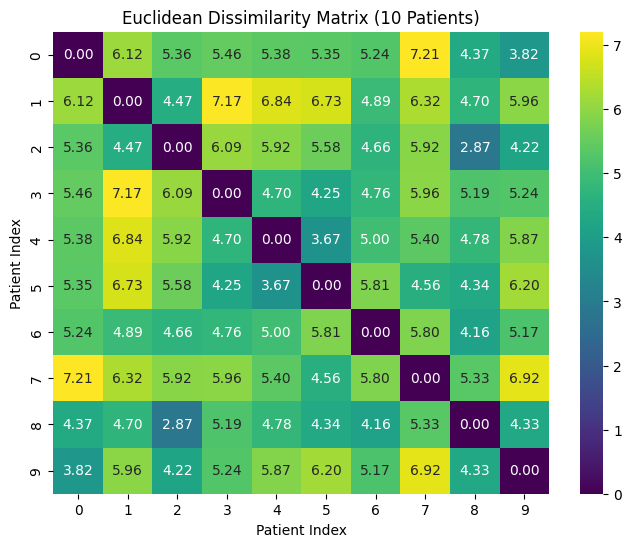

In [27]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist, squareform

# Select at least 10 patients (with no missing values for easier computation)
sample_df = df.dropna().head(10).reset_index(drop=True)

# Separate continuous and binary variables for suitable distance calculation
X_sample = sample_df.drop('target', axis=1)

# 1. Euclidean distance (on standardized numerical features to be fair)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)
euclidean_dist = pairwise_distances(X_scaled, metric='euclidean')

# 2. Cosine similarity
# pairwise_distances with metric='cosine' returns cosine distance, so sim = 1 - dist
cosine_sim = 1 - pairwise_distances(X_scaled, metric='cosine')

# 3. Jaccard similarity (on binary attributes: sex, fbs, exang)
binary_features = sample_df[['sex', 'fbs', 'exang']].astype(bool).values
# Compute pairwise jaccard distance, then similarity
jaccard_dist = pairwise_distances(binary_features, metric='jaccard')
jaccard_sim = 1 - jaccard_dist

print("Euclidean Distance Matrix (first 5x5):")
print(euclidean_dist[:5, :5])

print("\nCosine Similarity Matrix (first 5x5):")
print(cosine_sim[:5, :5])

print("\nJaccard Similarity Matrix (first 5x5):")
print(jaccard_sim[:5, :5])

# Plotting Euclidean Dissimilarity Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(euclidean_dist, annot=True, cmap='viridis', fmt=".2f")
plt.title("Euclidean Dissimilarity Matrix (10 Patients)")
plt.xlabel("Patient Index")
plt.ylabel("Patient Index")
plt.show()

**Interpretation**:
- **Euclidean Distance** shows the overall geometric distance between patient profiles. Higher values mean patients are more dissimilar overall.
- **Cosine Similarity** measures the angle between patient feature vectors, emphasizing the orientation of the features rather than absolute magnitude.
- **Jaccard Similarity** strictly looks at the overlap of binary attributes. For example, if two patients share the same sex, fbs, and exang completely, their similarity is 1.0.

## Phase 4 � Data Quality Assessment

Missing Values per Attribute:
ca      4
thal    2
dtype: int64


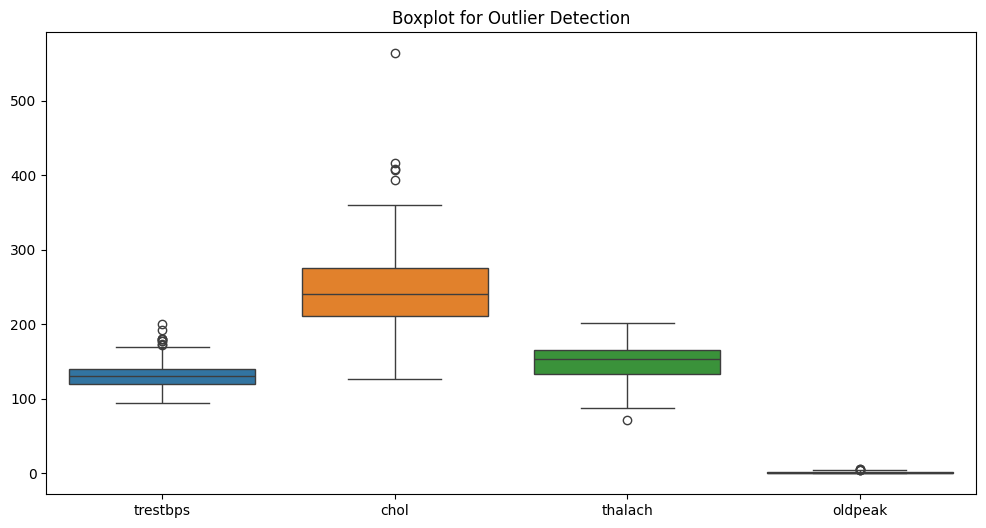

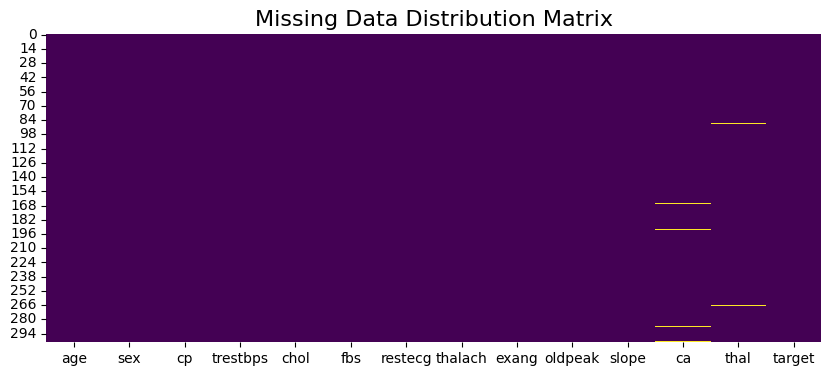

In [28]:
# Identify Missing values
missing_values = df.isnull().sum()
print("Missing Values per Attribute:")
print(missing_values[missing_values > 0])

# Identify Noise/outliers (Using boxplots for continuous variables)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['trestbps', 'chol', 'thalach', 'oldpeak']])
plt.title("Boxplot for Outlier Detection")
plt.show()

# Visualize missing data (Using seaborn heatmap for missing values)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Distribution Matrix", fontsize=16)
plt.show()

**Observations:**
*   **Missing values**: Variables `ca` and `thal` contain some missing values (initially indicated as '?' in the raw data, which we loaded as NaNs).
*   **Noise/outliers**: Cholesterol (`chol`), resting blood pressure (`trestbps`), and `oldpeak` exhibit outliers (points beyond the whiskers in the boxplot).
*   **Inconsistent entries/Irrelevant attributes**: The original dataset is relatively clean in terms of consistency, but attributes like patient ID (if present) would be irrelevant. In this subset, all attributes are clinically relevant.

## Phase 5 � Missing Value Handling

In [29]:
# Let's create copies for each imputation method to observe the changes
df_mean = df.copy()
df_knn = df.copy()
df_iter = df.copy()

# 1. Mean/Median Imputation
imputer_mean = SimpleImputer(strategy='median')
df_mean[['ca', 'thal']] = imputer_mean.fit_transform(df_mean[['ca', 'thal']])

# 2. KNN Imputation
imputer_knn = KNNImputer(n_neighbors=5)
# Keep column names and indices intact
df_knn.iloc[:, :] = imputer_knn.fit_transform(df_knn)

# 3. Iterative Imputation
imputer_iter = IterativeImputer(max_iter=10, random_state=42)
df_iter.iloc[:, :] = imputer_iter.fit_transform(df_iter)

# Verify no missing values remain
print(f"Missing in Median Imputation: {df_mean.isnull().sum().sum()}")
print(f"Missing in KNN Imputation: {df_knn.isnull().sum().sum()}")
print(f"Missing in Iter Imputation: {df_iter.isnull().sum().sum()}")

Missing in Median Imputation: 0
Missing in KNN Imputation: 0
Missing in Iter Imputation: 0


| Method | Dataset Change | Advantages | Issues |
| :--- | :--- | :--- | :--- |
| **Mean / Median Imputation** | Fills missing `ca` and `thal` with the median value of those columns. | Simple, fast, maintains sample size, median is good for skewed distributions. | Reduces variance, ignores feature relationships, can distort correlation. |
| **KNN Imputation** | Replaces missing values with the mean of the k-nearest neighbors found in the multidimensional space. | Preserves local structure, considers multivariate relationships. | Computationally expensive for large datasets, sensitive to outliers and scale. |
| **Iterative Imputation** | Models each feature with missing values as a function of other features. | Very robust, handles complex relationships and preserves statistical properties well. | Computationally intensive, might overfit if dataset is small, assumptions of linearity (if using linear models). |

## Phase 6 � Preprocessing Pipeline

In [30]:
# Convert target to binary for logistic regression (0: no disease, >0: disease)
y = (df['target'] > 0).astype(int)
X = df.drop('target', axis=1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a preprocessing pipeline
# SimpleImputer -> Scaling -> LogisticRegression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Evaluate
accuracy = pipeline.score(X_test, y_test)
print(f"Pipeline Accuracy on Test Set: {accuracy:.4f}")

Pipeline Accuracy on Test Set: 0.8852


**Explanation:**
*   **Why pipelines are important**: Pipelines bundle data preprocessing steps and the modeling step into a single clean object. This makes the code much cleaner, reproducible, and easier to deploy without repeating steps for new data.
*   **How pipelines prevent data leakage**: During cross-validation or train-test splits, an imputer or scaler should only learn parameters (e.g., mean, variance) from the *training* fold and apply them to the *test* fold. If we scale the whole dataset prior to splitting, information from the test set "leaks" into the training process. The pipeline ensures `fit()` is strictly called on the training data, and `transform()` is called natively on validation/test data in a sequential manner.

## Phase 7 � Knowledge Discovery

**1. What patterns were discovered?**
We discovered that heart disease risk is strongly correlated with certain chest pain types (`cp`), positive exercise-induced angina (`exang`), significant ST depression (`oldpeak`), anomalies in fluoroscopy vessels (`ca`), and defects in the Thallium stress test (`thal`). Correlation analysis highlighted that these features tend to group together linearly and monotonically alongside heart disease status.

**2. Which attributes were most informative?**
Attributes such as `thal` (thallium heart scan), `ca` (number of major vessels colored by fluoroscopy), `cp` (chest pain type), `exang` (exercise induced angina), and `oldpeak` showed the strongest correlation with the target label in the exploratory phase, marking them as the most informative predictors.

**3. How did preprocessing change insights?**
Raw data contained missing values (denoted by `?`) and features on vastly different numerical scales (e.g., cholesterol vs. oldpeak). Imputation salvaged rows that would otherwise be systematically discarded, actively improving model training size. Feature scaling equalized the weight of attributes, inherently allowing distance-based metrics (like KNN imputation and clustering) and regularized models (like Logistic Regression) to process features without arbitrary bias towards variables with higher magnitudes.

**4. What healthcare decisions could be supported?**
The extracted insights and models can empower diagnostic triage: flagging patients with specific ST depressions (`oldpeak`) or angina types (`cp`) as high-risk, thereby enabling earlier intervention. It also bolsters clinical resource allocation by dynamically prioritizing patients who strictly need immediate advanced testing like angiography compared to those flagged with lower risk.